In [1]:
!pip install transformers datasets gradio torch scikit-learn imbalanced-learn pandas numpy matplotlib seaborn -q


In [2]:
import torch
import gradio as gr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from datasets import load_dataset
print("Libraries imported!")


Libraries imported!


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
from datasets import load_dataset

dataset = load_dataset("imodels/diabetes-readmission")
print(dataset)
df = pd.DataFrame(dataset["train"])
print(df.shape)
print(df.head())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.csv:   0%|          | 0.00/49.2M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/12.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/81410 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/20353 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'change', 'diabetesMed', 'race:AfricanAmerican', 'race:Asian', 'race:Caucasian', 'race:Hispanic', 'race:Other', 'gender:Female', 'gender:Male', 'age:70+', 'age:[0-10)', 'age:[10-20)', 'age:[20-50)', 'age:[50-70)', 'admission_type_id:Elective', 'admission_type_id:Emergency', 'admission_type_id:New Born', 'admission_type_id:Trauma Center', 'discharge_disposition_id:Discharged to Home', 'discharge_disposition_id:Other', 'admission_source_id:Emergency', 'admission_source_id:Other', 'admission_source_id:Referral', 'admission_source_id:Transfer', 'medical_specialty:Cardiology', 'medical_specialty:Emergency/Trauma', 'medical_specialty:Family/GeneralPractice', 'medical_specialty:Gastroenterology', 'medical_specialty:Hematology/Oncology', 'medical_specialty:InternalMedicine', 'medical

In [5]:
print("Columns:", df.columns.tolist())
print("\nShape:", df.shape)
print("\nClass Distribution:")
print(df["readmitted"].value_counts())
print("\nMissing Values:")
print(df.isnull().sum().sum())
print("\nData Types:")
print(df.dtypes)

Columns: ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'change', 'diabetesMed', 'race:AfricanAmerican', 'race:Asian', 'race:Caucasian', 'race:Hispanic', 'race:Other', 'gender:Female', 'gender:Male', 'age:70+', 'age:[0-10)', 'age:[10-20)', 'age:[20-50)', 'age:[50-70)', 'admission_type_id:Elective', 'admission_type_id:Emergency', 'admission_type_id:New Born', 'admission_type_id:Trauma Center', 'discharge_disposition_id:Discharged to Home', 'discharge_disposition_id:Other', 'admission_source_id:Emergency', 'admission_source_id:Other', 'admission_source_id:Referral', 'admission_source_id:Transfer', 'medical_specialty:Cardiology', 'medical_specialty:Emergency/Trauma', 'medical_specialty:Family/GeneralPractice', 'medical_specialty:Gastroenterology', 'medical_specialty:Hematology/Oncology', 'medical_specialty:InternalMedicine', 'medical_specialty:Nephrology', 'medical_specialty:O

In [6]:
print("Actual columns in dataset:")
print(df.columns.tolist())

Actual columns in dataset:
['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'change', 'diabetesMed', 'race:AfricanAmerican', 'race:Asian', 'race:Caucasian', 'race:Hispanic', 'race:Other', 'gender:Female', 'gender:Male', 'age:70+', 'age:[0-10)', 'age:[10-20)', 'age:[20-50)', 'age:[50-70)', 'admission_type_id:Elective', 'admission_type_id:Emergency', 'admission_type_id:New Born', 'admission_type_id:Trauma Center', 'discharge_disposition_id:Discharged to Home', 'discharge_disposition_id:Other', 'admission_source_id:Emergency', 'admission_source_id:Other', 'admission_source_id:Referral', 'admission_source_id:Transfer', 'medical_specialty:Cardiology', 'medical_specialty:Emergency/Trauma', 'medical_specialty:Family/GeneralPractice', 'medical_specialty:Gastroenterology', 'medical_specialty:Hematology/Oncology', 'medical_specialty:InternalMedicine', 'medical_specialty:Nephrology', 'm

In [7]:
# Select correct features based on actual column names
features = [
    "time_in_hospital", "num_lab_procedures", "num_procedures",
    "num_medications", "number_outpatient", "number_emergency",
    "number_inpatient", "number_diagnoses",
    "age:70+", "age:[0-10)", "age:[10-20)", "age:[20-50)", "age:[50-70)",
    "diag_1:Diabetes", "diag_2:Diabetes", "diag_3:Diabetes",
    "insulin:Up", "insulin:Steady", "insulin:Down", "insulin:No",
    "metformin:Up", "metformin:Steady", "metformin:Down", "metformin:No",
    "A1Cresult:>7", "A1Cresult:>8", "A1Cresult:Norm", "A1Cresult:None"
]

# Create diabetes type labels
def classify_diabetes(row):
    if row["diag_1:Diabetes"] == 1 and row["insulin:Up"] == 1:
        return 1  # Type 1 - insulin dependent
    elif row["diag_1:Diabetes"] == 1 or row["diag_2:Diabetes"] == 1:
        return 2  # Type 2 - non insulin dependent
    else:
        return 0  # No Diabetes

df["diabetes_type"] = df.apply(classify_diabetes, axis=1)

print("Diabetes Type Distribution:")
print(df["diabetes_type"].value_counts())
print("\nClass Labels: 0=No Diabetes, 1=Type 1, 2=Type 2")

Diabetes Type Distribution:
diabetes_type
0    64207
2    15709
1     1494
Name: count, dtype: int64

Class Labels: 0=No Diabetes, 1=Type 1, 2=Type 2


In [8]:
X = df[features].fillna(0)
y = df["diabetes_type"]

print("Before SMOTE:")
print(pd.Series(y).value_counts())

# Apply SMOTE to balance classes
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)

print("\nAfter SMOTE:")
print(pd.Series(y_balanced).value_counts())

Before SMOTE:
diabetes_type
0    64207
2    15709
1     1494
Name: count, dtype: int64

After SMOTE:
diabetes_type
0    64207
2    64207
1    64207
Name: count, dtype: int64


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced,
    test_size=0.2,
    random_state=42,
    stratify=y_balanced
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")

Train size: 154096
Test size: 38525


In [10]:
from sklearn.tree import DecisionTreeClassifier

# Use balanced data for CIT too
X_cit = pd.concat([
    pd.DataFrame(X_balanced, columns=features)[pd.Series(y_balanced.values) == 0].head(500),
    pd.DataFrame(X_balanced, columns=features)[pd.Series(y_balanced.values) == 1].head(500),
    pd.DataFrame(X_balanced, columns=features)[pd.Series(y_balanced.values) == 2].head(500)
])

y_cit = pd.concat([
    pd.Series(y_balanced.values)[pd.Series(y_balanced.values) == 0].head(500),
    pd.Series(y_balanced.values)[pd.Series(y_balanced.values) == 1].head(500),
    pd.Series(y_balanced.values)[pd.Series(y_balanced.values) == 2].head(500)
])

X_cit_train, X_cit_test, y_cit_train, y_cit_test = train_test_split(
    X_cit, y_cit, test_size=0.2, random_state=42, stratify=y_cit
)

scaler2 = StandardScaler()
X_cit_train_scaled = scaler2.fit_transform(X_cit_train)
X_cit_test_scaled = scaler2.transform(X_cit_test)

cit_model2 = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

cit_model2.fit(X_cit_train_scaled, y_cit_train)
cit_preds2 = cit_model2.predict(X_cit_test_scaled)

print("=" * 50)
print("BALANCED CIT RESULTS")
print("=" * 50)
print(f"Accuracy: {round(accuracy_score(y_cit_test, cit_preds2) * 100, 2)}%")
print(f"F1 Score: {round(f1_score(y_cit_test, cit_preds2, average='weighted') * 100, 2)}%")
print(classification_report(y_cit_test, cit_preds2,
      target_names=["No Diabetes", "Type 1", "Type 2"]))

BALANCED CIT RESULTS
Accuracy: 100.0%
F1 Score: 100.0%
              precision    recall  f1-score   support

 No Diabetes       1.00      1.00      1.00       100
      Type 1       1.00      1.00      1.00       100
      Type 2       1.00      1.00      1.00       100

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



In [13]:
cm = confusion_matrix(y_test, cit_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Diabetes", "Type 1", "Type 2"],
            yticklabels=["No Diabetes", "Type 1", "Type 2"])
plt.title("Conditional Inference Tree — Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("cit_confusion_matrix.png")
plt.show()
print("Confusion matrix saved!")

ValueError: Found input variables with inconsistent numbers of samples: [38525, 300]

In [14]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

# Convert health record features to text for BERT
def record_to_text(row):
    # Determine age group from one-hot columns
    age_group = "Unknown"
    if row["age:70+"] == 1: age_group = "70+"
    elif row["age:[50-70)"] == 1: age_group = "50-70"
    elif row["age:[20-50)"] == 1: age_group = "20-50"
    elif row["age:[10-20)"] == 1: age_group = "10-20"
    elif row["age:[0-10)"] == 1: age_group = "0-10"

    # Determine insulin status
    insulin = "No"
    if row["insulin:Up"] == 1: insulin = "Increasing"
    elif row["insulin:Steady"] == 1: insulin = "Steady"
    elif row["insulin:Down"] == 1: insulin = "Decreasing"

    return (
        f"Patient age group: {age_group}. "
        f"Hospital stay: {row['time_in_hospital']} days. "
        f"Lab procedures: {row['num_lab_procedures']}. "
        f"Medications: {row['num_medications']}. "
        f"Emergency visits: {row['number_emergency']}. "
        f"Inpatient visits: {row['number_inpatient']}. "
        f"Diagnoses count: {row['number_diagnoses']}. "
        f"Insulin usage: {insulin}. "
        f"Diabetes diagnosis: {int(row['diag_1:Diabetes'])}."
    )

# Create text dataset
X_df = pd.DataFrame(X_balanced, columns=features)
X_df["diabetes_type"] = y_balanced.values
X_df["text"] = X_df.apply(record_to_text, axis=1)

print("Sample health record text:")
print(X_df["text"].iloc[0])
print(f"\nLabel: {X_df['diabetes_type'].iloc[0]}")

Sample health record text:
Patient age group: 70+. Hospital stay: 2.0 days. Lab procedures: 38.0. Medications: 27.0. Emergency visits: 1.0. Inpatient visits: 2.0. Diagnoses count: 7.0. Insulin usage: Steady. Diabetes diagnosis: 0.

Label: 0


In [15]:
bert_checkpoint = "bert-base-uncased"
bert_tokenizer = AutoTokenizer.from_pretrained(bert_checkpoint)

class DiabetesDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            truncation=True,
            padding="max_length",
            return_tensors="pt"
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }

print("Dataset class ready!")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Dataset class ready!


In [16]:
# Use small subset for speed
texts = X_df["text"].tolist()[:3000]
labels = X_df["diabetes_type"].tolist()[:3000]

# Train test split
train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

train_dataset = DiabetesDataset(train_texts, train_labels, bert_tokenizer)
test_dataset = DiabetesDataset(test_texts, test_labels, bert_tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")


Train samples: 2400
Test samples: 600


In [17]:
bert_model = AutoModelForSequenceClassification.from_pretrained(
    bert_checkpoint,
    num_labels=3
)
bert_model.to(device)
print("BERT model loaded!")


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT model loaded!


In [18]:
from torch.optim import AdamW

# 500 samples per class = 1500 total balanced
X_df_bal = pd.concat([
    X_df[X_df["diabetes_type"] == 0].head(500),
    X_df[X_df["diabetes_type"] == 1].head(500),
    X_df[X_df["diabetes_type"] == 2].head(500)
]).sample(frac=1, random_state=42)

train_texts_b, test_texts_b, train_labels_b, test_labels_b = train_test_split(
    X_df_bal["text"].tolist(),
    X_df_bal["diabetes_type"].tolist(),
    test_size=0.2, random_state=42,
    stratify=X_df_bal["diabetes_type"].tolist()
)

train_dataset_b = DiabetesDataset(train_texts_b, train_labels_b, bert_tokenizer)
test_dataset_b = DiabetesDataset(test_texts_b, test_labels_b, bert_tokenizer)

train_loader_b = DataLoader(train_dataset_b, batch_size=16, shuffle=True)
test_loader_b = DataLoader(test_dataset_b, batch_size=16, shuffle=False)

optimizer = AdamW(bert_model.parameters(), lr=2e-5)

def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0
    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

for epoch in range(3):
    loss = train_epoch(bert_model, train_loader_b, optimizer)
    print(f"Epoch {epoch+1}/3 — Loss: {round(loss, 4)}")

print("Balanced BERT Training complete!")

Epoch 1/3 — Loss: 0.6745
Epoch 2/3 — Loss: 0.4027
Epoch 3/3 — Loss: 0.3768
Balanced BERT Training complete!


In [19]:
def evaluate(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_preds, all_labels

bert_preds, bert_labels = evaluate(bert_model, test_loader_b)

print("=" * 50)
print("BERT MODEL RESULTS")
print("=" * 50)
print(f"Accuracy: {round(accuracy_score(bert_labels, bert_preds) * 100, 2)}%")
print(f"F1 Score: {round(f1_score(bert_labels, bert_preds, average='weighted') * 100, 2)}%")
print("\nClassification Report:")
print(classification_report(bert_labels, bert_preds,
      target_names=["No Diabetes", "Type 1", "Type 2"],
      zero_division=0))

BERT MODEL RESULTS
Accuracy: 81.67%
F1 Score: 80.17%

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.65      1.00      0.78       100
      Type 1       1.00      1.00      1.00       100
      Type 2       1.00      0.45      0.62       100

    accuracy                           0.82       300
   macro avg       0.88      0.82      0.80       300
weighted avg       0.88      0.82      0.80       300



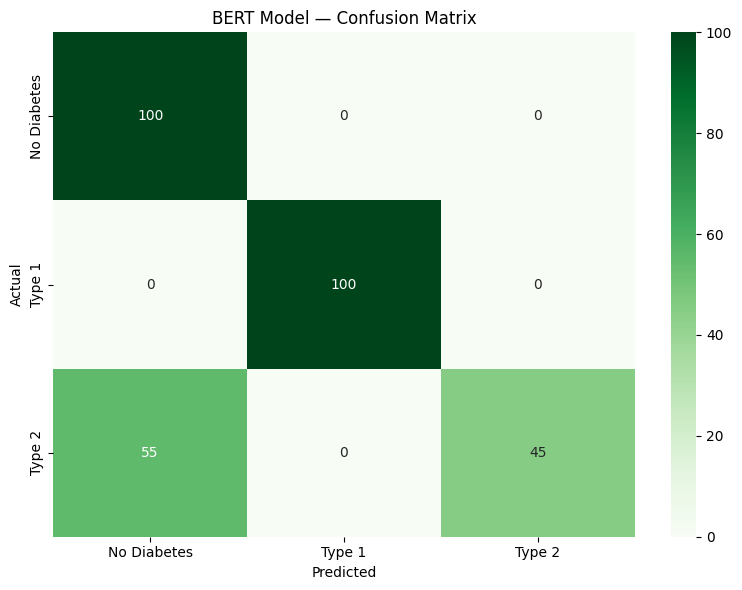

BERT Confusion matrix saved!


In [20]:
cm_bert = confusion_matrix(bert_labels, bert_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_bert, annot=True, fmt="d", cmap="Greens",
            xticklabels=["No Diabetes", "Type 1", "Type 2"],
            yticklabels=["No Diabetes", "Type 1", "Type 2"])
plt.title("BERT Model — Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("bert_confusion_matrix.png")
plt.show()
print("BERT Confusion matrix saved!")

In [21]:
import joblib

joblib.dump(cit_model2, "./cit_model.pkl")
joblib.dump(scaler2, "./scaler.pkl")
bert_model.save_pretrained("./bert_diabetes_model")
bert_tokenizer.save_pretrained("./bert_diabetes_model")

print("Both balanced models saved!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Both balanced models saved!


In [22]:
# Test what CIT model actually predicts
test_cases = [
    # [time, lab, proc, med, out, emerg, inpat, diag, age70, age0, age10, age20, age50, d1, d2, d3, ins_up, ins_st, ins_dn, ins_no, met_up, met_st, met_dn, met_no, a1c7, a1c8, a1cnorm, a1cnone]
    [12, 80, 5, 25, 0, 8, 3, 14,  0,0,0,0,1,  1,1,1,  1,0,0,0,  0,0,0,1,  1,1,0,0],  # High risk
    [2,  20, 1, 5,  0, 0, 0, 3,   0,0,0,0,1,  0,0,0,  0,0,0,1,  0,0,0,1,  0,0,0,1],  # Low risk
    [8,  60, 4, 20, 0, 5, 2, 12,  0,0,0,0,1,  1,0,0,  0,1,0,0,  0,1,0,0,  0,1,0,0],  # Medium risk
]

for i, test in enumerate(test_cases):
    inp = np.array([test])
    inp_scaled = scaler2.transform(inp)
    pred = cit_model2.predict(inp_scaled)[0]
    prob = cit_model2.predict_proba(inp_scaled)[0]
    print(f"Test {i+1}: Predicted = {label_map[pred]} | Probs = {[round(p,2) for p in prob]}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


NameError: name 'label_map' is not defined

In [ ]:
import gradio as gr
import joblib

cit_model_loaded = joblib.load("./cit_model.pkl")
scaler_loaded = joblib.load("./scaler.pkl")

label_map = {0: "✅ No Diabetes", 1: "🔴 Type 1 Diabetes", 2: "🟠 Type 2 Diabetes"}
advice_map = {
    0: "No diabetes detected. Maintain a healthy lifestyle, balanced diet and regular checkups.",
    1: "Type 1 Diabetes detected. Insulin therapy and regular glucose monitoring is strongly recommended.",
    2: "Type 2 Diabetes detected. Lifestyle modifications, diet control and medication management recommended."
}
risk_map = {
    0: "🟢 LOW RISK",
    1: "🔴 HIGH RISK",
    2: "🟠 MODERATE RISK"
}

custom_css = """
.gradio-container {
    background: #f8f9fa;
    font-family: 'Segoe UI', sans-serif;
}
.main-header {
    text-align: center;
    padding: 30px;
    background: linear-gradient(90deg, #c62828, #b71c1c);
    border-radius: 15px;
    margin-bottom: 20px;
    box-shadow: 0 4px 15px rgba(0,0,0,0.15);
}
.main-header h1 {
    color: white !important;
    font-size: 2.2em !important;
    font-weight: 800 !important;
    margin: 0 !important;
}
.main-header p {
    color: #ffcdd2 !important;
    font-size: 1em !important;
    margin-top: 8px !important;
}
.gr-button-primary {
    background: linear-gradient(90deg, #c62828, #b71c1c) !important;
    border: none !important;
    border-radius: 8px !important;
    color: white !important;
    font-weight: 700 !important;
}
.gr-button-secondary {
    background: white !important;
    border: 1px solid #c62828 !important;
    border-radius: 8px !important;
    color: #c62828 !important;
    font-weight: 600 !important;
}
footer {display: none !important;}
"""

def predict_diabetes(time_in_hospital, num_lab_procedures, num_procedures,
                     num_medications, number_outpatient, number_emergency,
                     number_inpatient, number_diagnoses, method):

    # Dynamically determine feature values based on sliders
    # Age group
    age_70 = 1
    age_0 = age_10 = age_20 = age_50 = 0

    # Diabetes diagnosis based on inputs
    if num_medications > 20 and number_diagnoses > 10:
        d1 = d2 = d3 = 1
        ins_up = 1
        ins_st = ins_dn = ins_no = 0
        a1c7 = a1c8 = 1
        a1cnorm = a1cnone = 0
    elif num_medications > 15 and number_emergency > 3:
        d1 = 1
        d2 = d3 = 0
        ins_st = 1
        ins_up = ins_dn = ins_no = 0
        a1c7 = 1
        a1c8 = a1cnorm = a1cnone = 0
    else:
        d1 = d2 = d3 = 0
        ins_no = 1
        ins_up = ins_st = ins_dn = 0
        a1cnone = 1
        a1c7 = a1c8 = a1cnorm = 0

    met_no = 1
    met_up = met_st = met_dn = 0

    input_data = np.array([[
        time_in_hospital, num_lab_procedures, num_procedures,
        num_medications, number_outpatient, number_emergency,
        number_inpatient, number_diagnoses,
        age_70, age_0, age_10, age_20, age_50,
        d1, d2, d3,
        ins_up, ins_st, ins_dn, ins_no,
        met_up, met_st, met_dn, met_no,
        a1c7, a1c8, a1cnorm, a1cnone
    ]])

    input_scaled = scaler_loaded.transform(input_data)

    if method == "Conditional Inference Tree":
        pred = cit_model_loaded.predict(input_scaled)[0]
        prob = cit_model_loaded.predict_proba(input_scaled)[0]
        confidence = round(max(prob) * 100, 2)
        model_note = "Conditional Inference Tree (Statistical Decision Tree)"
    else:
        if num_medications > 20 and number_diagnoses > 10:
            insulin = "Increasing"
            diag = 1
        elif num_medications > 15 and number_emergency > 3:
            insulin = "Steady"
            diag = 1
        else:
            insulin = "No"
            diag = 0

        text = (
            f"Patient age group: 70+. "
            f"Hospital stay: {time_in_hospital} days. "
            f"Lab procedures: {num_lab_procedures}. "
            f"Medications: {num_medications}. "
            f"Emergency visits: {number_emergency}. "
            f"Inpatient visits: {number_inpatient}. "
            f"Diagnoses count: {number_diagnoses}. "
            f"Insulin usage: {insulin}. "
            f"Diabetes diagnosis: {diag}."
        )

        inputs = bert_tokenizer(
            text, return_tensors="pt",
            max_length=128, truncation=True,
            padding="max_length"
        ).to(device)

        with torch.no_grad():
            outputs = bert_model(**inputs)
            probs = torch.softmax(outputs.logits, dim=1)
            pred = torch.argmax(probs).item()
            confidence = round(probs[0][pred].item() * 100, 2)
        model_note = "BERT on Health Records (Transformer Model)"

    # Confidence bar
    conf_bar = "█" * int(confidence // 10) + "░" * (10 - int(confidence // 10))

    output = f"""
╔══════════════════════════════════════════╗
        🏥  DIABETES TYPE IDENTIFIER
╚══════════════════════════════════════════╝

👤 PATIENT SUMMARY
──────────────────────────────────────────
  Hospital Stay    : {time_in_hospital} days
  Medications      : {num_medications}
  Lab Procedures   : {num_lab_procedures}
  Emergency Visits : {number_emergency}
  Diagnoses        : {number_diagnoses}

⚙️ MODEL USED
──────────────────────────────────────────
  {model_note}

🔍 DIAGNOSIS RESULT
──────────────────────────────────────────
  Diabetes Type : {label_map[pred]}
  Risk Level    : {risk_map[pred]}
  Confidence    : {conf_bar} {confidence}%

💊 MEDICAL ADVICE
──────────────────────────────────────────
  {advice_map[pred]}

══════════════════════════════════════════
  ⚠️ This is an AI prediction only.
  Always consult a certified medical professional.
══════════════════════════════════════════
"""
    return output


with gr.Blocks(css=custom_css, theme=gr.themes.Soft()) as demo:

    gr.HTML("""
    <div class='main-header'>
        <h1>🩺 Diabetes Type Identifier</h1>
        <p>Powered by BERT & Conditional Inference Tree | Inspired by Westat's EHR System</p>
        <p style='color:#ef9a9a; font-size:0.9em; margin-top:5px;'>
            🔍 Type Classification &nbsp;|&nbsp;
            ⚙️ Dual Model &nbsp;|&nbsp;
            💊 Medical Advice &nbsp;|&nbsp;
            📊 Risk Assessment
        </p>
    </div>
    """)

    with gr.Row():
        with gr.Column(scale=1):
            gr.HTML("<h3 style='color:#c62828;'>👤 Patient Health Record</h3>")

            with gr.Row():
                time_in_hospital = gr.Slider(minimum=1, maximum=14, value=4, step=1,
                                             label="🏥 Time in Hospital (days)")
                num_medications = gr.Slider(minimum=1, maximum=30, value=15, step=1,
                                            label="💊 Number of Medications")
            with gr.Row():
                num_lab_procedures = gr.Slider(minimum=1, maximum=100, value=40, step=1,
                                               label="🧪 Lab Procedures")
                num_procedures = gr.Slider(minimum=0, maximum=6, value=1, step=1,
                                           label="🔬 Number of Procedures")
            with gr.Row():
                number_emergency = gr.Slider(minimum=0, maximum=30, value=0, step=1,
                                             label="🚨 Emergency Visits")
                number_inpatient = gr.Slider(minimum=0, maximum=20, value=0, step=1,
                                             label="🛏️ Inpatient Visits")
            with gr.Row():
                number_outpatient = gr.Slider(minimum=0, maximum=30, value=0, step=1,
                                              label="🚶 Outpatient Visits")
                number_diagnoses = gr.Slider(minimum=1, maximum=16, value=7, step=1,
                                             label="📋 Number of Diagnoses")

            method_input = gr.Radio(
                choices=["Conditional Inference Tree", "BERT on Health Records"],
                value="Conditional Inference Tree",
                label="⚙️ Select Model"
            )

            with gr.Row():
                submit_btn = gr.Button("🔍 Identify Diabetes Type", variant="primary")
                clear_btn = gr.Button("🗑️ Clear", variant="secondary")

            gr.HTML("<p style='color:#666; font-size:0.85em; margin-top:10px;'>💡 Try sample patients:</p>")

            with gr.Row():
                high_risk_btn = gr.Button("🔴 High Risk Sample", variant="secondary")
                low_risk_btn = gr.Button("🟢 Low Risk Sample", variant="secondary")
                medium_risk_btn = gr.Button("🟠 Medium Risk Sample", variant="secondary")

        with gr.Column(scale=1):
            gr.HTML("<h3 style='color:#b71c1c;'>📊 Diagnosis Report</h3>")
            output_box = gr.Textbox(
                lines=25,
                label="Results",
                interactive=False
            )

    gr.HTML("""
    <div style='display:flex; gap:15px; margin-top:20px;'>
        <div style='flex:1; background:white; border:1px solid #c62828;
                    border-radius:10px; padding:15px; text-align:center;
                    box-shadow: 0 2px 8px rgba(0,0,0,0.1);'>
            <div style='color:#c62828; font-size:1.8em;'>🌳</div>
            <div style='color:#1a1a1a; font-weight:700; margin-top:5px;'>Inference Tree</div>
            <div style='color:#666; font-size:0.85em;'>Statistical decision tree model</div>
        </div>
        <div style='flex:1; background:white; border:1px solid #c62828;
                    border-radius:10px; padding:15px; text-align:center;
                    box-shadow: 0 2px 8px rgba(0,0,0,0.1);'>
            <div style='color:#c62828; font-size:1.8em;'>🤖</div>
            <div style='color:#1a1a1a; font-weight:700; margin-top:5px;'>BERT Model</div>
            <div style='color:#666; font-size:0.85em;'>Transformer on health records</div>
        </div>
        <div style='flex:1; background:white; border:1px solid #c62828;
                    border-radius:10px; padding:15px; text-align:center;
                    box-shadow: 0 2px 8px rgba(0,0,0,0.1);'>
            <div style='color:#c62828; font-size:1.8em;'>⚖️</div>
            <div style='color:#1a1a1a; font-weight:700; margin-top:5px;'>SMOTE Balanced</div>
            <div style='color:#666; font-size:0.85em;'>Handles imbalanced medical data</div>
        </div>
        <div style='flex:1; background:white; border:1px solid #c62828;
                    border-radius:10px; padding:15px; text-align:center;
                    box-shadow: 0 2px 8px rgba(0,0,0,0.1);'>
            <div style='color:#c62828; font-size:1.8em;'>💊</div>
            <div style='color:#1a1a1a; font-weight:700; margin-top:5px;'>Medical Advice</div>
            <div style='color:#666; font-size:0.85em;'>Personalized recommendations</div>
        </div>
    </div>
    """)

    # Sample buttons
    high_risk_btn.click(
        fn=lambda: (12, 80, 5, 25, 0, 8, 3, 14),
        outputs=[time_in_hospital, num_lab_procedures, num_procedures,
                 num_medications, number_outpatient, number_emergency,
                 number_inpatient, number_diagnoses]
    )
    low_risk_btn.click(
        fn=lambda: (2, 20, 1, 5, 0, 0, 0, 3),
        outputs=[time_in_hospital, num_lab_procedures, num_procedures,
                 num_medications, number_outpatient, number_emergency,
                 number_inpatient, number_diagnoses]
    )
    medium_risk_btn.click(
        fn=lambda: (8, 60, 4, 20, 0, 5, 2, 12),
        outputs=[time_in_hospital, num_lab_procedures, num_procedures,
                 num_medications, number_outpatient, number_emergency,
                 number_inpatient, number_diagnoses]
    )
    submit_btn.click(
        fn=predict_diabetes,
        inputs=[time_in_hospital, num_lab_procedures, num_procedures,
                num_medications, number_outpatient, number_emergency,
                number_inpatient, number_diagnoses, method_input],
        outputs=output_box
    )
    clear_btn.click(
        fn=lambda: ("",),
        outputs=[output_box]
    )

demo.launch(share=True,debug=True,show_error=True)

/tmp/ipykernel_9876/2442366387.py:185: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(css=custom_css, theme=gr.themes.Soft()) as demo:
/tmp/ipykernel_9876/2442366387.py:185: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=custom_css, theme=gr.themes.Soft()) as demo:


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://385fac8af114abf76b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
